# Import Environment variables

In [27]:
%run /home/jupyter/repos/Multi-trait-GWAS-in-admixed-populations/notebooks/Setting_Env_Variables.ipynb

Found bucket: id=rw-migration-aou-rw-f7a4d148, bucketName=rw-migration-aou-rw-f7a4d148
-> Assigned migration variables (ID: rw-migration-aou-rw-f7a4d148)
Found bucket: id=temporary-workspace-bucket, bucketName=temporary-workspace-bucket-wb-perky-cabbage-8342
Found bucket: id=workspace-bucket, bucketName=workspace-bucket-wb-perky-cabbage-8342
✅ Successfully identified latest dataset: wb-silky-artichoke-2408.C2024Q3R9

Variables extracted:
GOOGLE_CLOUD_PROJECT: wb-perky-cabbage-8342
WORKSPACE_BUCKET: gs://workspace-bucket-wb-perky-cabbage-8342
WORKSPACE_TEMP_BUCKET: gs://temporary-workspace-bucket-wb-perky-cabbage-8342
WORKSPACE_CDR: wb-silky-artichoke-2408.C2024Q3R9
bucket_aou_tutorial: NOT FOUND
bucket_id_aou_tutorial: NOT FOUND
bucket_migrated: gs://rw-migration-aou-rw-f7a4d148
bucket_id_migrated: rw-migration-aou-rw-f7a4d148

✅ Saved to /home/jupyter/.bashrc
C2024Q3R9 BQ_DATASET
Multi-trait-GWAS-in-admixed-populations GIT_REPO
dataset_test2 BQ_DATASET
prep_C2024Q3R9 BQ_DATASET
rw-mig

In [28]:
%run /home/jupyter/repos/Multi-trait-GWAS-in-admixed-populations/notebooks/Setting_Env_Variables_p2.ipynb

WORKSPACE_CDR = wb-silky-artichoke-2408.C2024Q3R9
WORKSPACE_BUCKET = gs://workspace-bucket-wb-perky-cabbage-8342
GOOGLE_PROJECT = wb-perky-cabbage-8342
Done! 10 variables saved to: /home/jupyter/repos/Multi-trait-GWAS-in-admixed-populations/notebooks/Setting_Env_Variables_p2.R
Done! 10 variables saved to: /home/jupyter/repos/Multi-trait-GWAS-in-admixed-populations/notebooks/Setting_Env_Variables.sas


# Librairy

In [29]:
%load_ext autoreload
%autoreload 2

import os
import subprocess
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
from itertools import combinations

from my_function import optim_plot_prevalence

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Data's import

## Data from 50_Breast_Cancer_WINTHIN_5Y

Femmes n'ayant pas eu de cancer avant l'inclusion (BC and not BC included without time constraints) for all time)

In [30]:
# get the bucket name
my_bucket = os.getenv('WORKSPACE_BUCKET')
name_of_file_in_bucket = "df_bc_ko_at_inclusion_361k_nb_BC_WITHIN_5Y.tsv"

# save dataframe in a csv file in the same workspace as the notebook
df_bc = pd.read_csv(my_bucket+'/Data/'+name_of_file_in_bucket)
df_bc

,person_id,gender,date_of_birth,ethnicity,self_reported_category,inclusion_date,first_breast_cancer_date,delay_days,delay_years,time_category,age_at_inclusion,has_bc
0,7604109,Female,1953-06-15,Not Hispanic or Latino,Native Hawaiian or Other Pacific Islander,2022-03-29,NaN,NaN,NaN,NaN,68.785763,0
1,3093241,Female,1962-06-15,Not Hispanic or Latino,Native Hawaiian or Other Pacific Islander,2021-11-02,NaN,NaN,NaN,NaN,59.383984,0
2,7388718,Female,1987-06-15,Not Hispanic or Latino,Native Hawaiian or Other Pacific Islander,2022-04-12,NaN,NaN,NaN,NaN,34.825462,0
3,2382559,Female,1988-06-15,Not Hispanic or Latino,Native Hawaiian or Other Pacific Islander,2022-04-04,NaN,NaN,NaN,NaN,33.801506,0
4,2032331,Female,1954-06-15,Not Hispanic or Latino,Native Hawaiian or Other Pacific Islander,2019-09-17,NaN,NaN,NaN,NaN,65.256674,0
...,...,...,...,...,...,...,...,...,...,...,...,...
360881,4702863,Female,2003-06-15,Not Hispanic or Latino,White,2023-02-24,NaN,NaN,NaN,NaN,19.696099,0
360882,6582005,Female,2003-06-15,Not Hispanic or Latino,White,2023-06-03,NaN,NaN,NaN,NaN,19.967146,0
360883,6678789,Female,2004-06-15,Not Hispanic or Latino,White,2023-08-24,NaN,NaN,NaN,NaN,19.189596,0
360884,1196731,Female,2004-06-15,Not Hispanic or Latino,White,2023-08-24,NaN,NaN,NaN,NaN,19.189596,0


## Importing genetic ancestry data (RYE)

In [31]:
!gcloud storage cp gs://vwb-aou-datasets-controlled/v8/wgs/short_read/snpindel/aux/admixture_estimates/aou_admixture_estimates_rye_v8.Q $WORKSPACE_TEMP_BUCKET/ --billing-project=$GOOGLE_PROJECT

Copying gs://vwb-aou-datasets-controlled/v8/wgs/short_read/snpindel/aux/admixture_estimates/aou_admixture_estimates_rye_v8.Q to gs://temporary-workspace-bucket-wb-perky-cabbage-8342/aou_admixture_estimates_rye_v8.Q
  Completed files 1/1 | 32.5MiB/32.5MiB                                        


### srWGS genetic admixture estimates - Clarification

Nous fournissons des estimations d'ascendance génétique pour tous les échantillons disposant de données srWGS aux formats .Q et FAM. L'analyse a été réalisée avec l'outil Rye.

Le fichier .Q contient des colonnes indiquant les groupes d'ascendance utilisés dans les données d'entraînement, et les lignes correspondent aux estimations d'admixture pour chaque échantillon. Les étiquettes de groupes d'ascendance utilisées sont : 1KGP-HGDP-AFR-like (AFR), 1KGP-HGDP-AMR-like (AMR), 1KGP-HGDP-EAS-like (EAS), 1KGP-HGDP-EUR-like (EUR), 1KGP-HGDP-MID-like (MID), 1KGP-HGDP-SAS-like (SAS) et Individus restants (OTH). Nous fournissons également les estimations d'admixture de référence.

Le fichier .fam contient les informations relatives à la façon dont chaque individu a été associé aux données d'entraînement.

Veuillez noter : les estimations de métissage génétique pour les personnes d’ascendance américaine pourraient être incomplètes en raison du manque d’échantillons appropriés dans les jeux de données de génomes de référence publics (1KGP-HGDP en l’occurrence) pour prendre en compte l’ensemble des différences au sein de ce groupe. Cette imprécision peut également exister pour d’autres populations mondiales pour lesquelles les données de référence sont limitées, comme les populations du Moyen-Orient. De plus, les estimations de proportion d’ascendance pour les participants de l’étude « All of Us » appartenant au groupe d’ascendance génétique similaire à 1KGP-HGDP-AMR sont influencées par la présence de métissage dans les génomes des individus 1KGP-HGDP-AMR inclus dans les jeux de données de référence, ce qui affecte leur précision. Nous recommandons la prudence lors de l’interprétation de ces estimations, car elles pourraient ne pas refléter pleinement la richesse génétique de la population des Amériques.

Source -> [support.researchallofus.org](https://support.researchallofus.org/hc/en-us/articles/29475228181908-How-the-All-of-Us-Genomic-data-are-organized-Archived-CDRv8#h_01GY7QYC017WWMXFB0YTT233G1:~:text=srWGS%20genetic%20admixture%20estimates)

In [32]:
# get the bucket name
my_bucket = os.getenv('WORKSPACE_TEMP_BUCKET')
name_of_file_in_bucket = "aou_admixture_estimates_rye_v8.Q"

# save dataframe in a csv file in the same workspace as the notebook
df_rye = pd.read_csv(my_bucket+'/'+name_of_file_in_bucket, sep='\t')
df_rye

,eur,eas,amr,afr,sas,mid,research_id
0,0.000000,0.002611,0.000000,0.940905,0.000000,0.056484,1000000
1,0.892052,0.000000,0.063450,0.000000,0.000000,0.044498,1000004
2,0.886335,0.000000,0.039803,0.000000,0.073862,0.000000,1000033
3,0.045004,0.003594,0.000000,0.874350,0.003528,0.073524,1000039
4,0.115799,0.014158,0.000000,0.853614,0.000000,0.016430,1000042
...,...,...,...,...,...,...,...
414825,0.913647,0.000000,0.028156,0.000000,0.029290,0.028907,9999678
414826,0.000000,0.000000,0.947722,0.000000,0.032638,0.019640,9999697
414827,0.913319,0.000000,0.044853,0.000000,0.018338,0.023490,9999715
414828,0.604467,0.000000,0.020042,0.052073,0.000000,0.323418,9999755


# Genetic data processing

## Rename the columns

In [33]:
df_rye.rename(columns={'eur':'eur_rye',
                       'eas':'eas_rye',
                       'amr':'amr_rye',
                       'afr':'afr_rye',
                       'sas':'sas_rye',
                       'mid':'mid_rye'}, inplace=True)

## Merge with the main data set

In [34]:
df = pd.merge(df_bc, df_rye, left_on='person_id', right_on='research_id', how='left', indicator=True)

### Répartition des femmes ne disposant pas d'information sur leur ascendance génétique en fonction de `has_bc`

In [35]:
df[df['_merge'] == "left_only"].value_counts('has_bc')

has_bc
0    137395
1       285
Name: count, dtype: int64

In [36]:
df[df['has_bc'] == 1].count()

person_id                   1588
gender                      1588
date_of_birth               1588
ethnicity                   1588
self_reported_category      1588
inclusion_date              1588
first_breast_cancer_date    1588
delay_days                  1588
delay_years                 1588
time_category               1574
age_at_inclusion            1588
has_bc                      1588
eur_rye                     1303
eas_rye                     1303
amr_rye                     1303
afr_rye                     1303
sas_rye                     1303
mid_rye                     1303
research_id                 1303
_merge                      1588
dtype: int64

In [37]:
df['_merge'].value_counts()

_merge
both          223206
left_only     137680
right_only         0
Name: count, dtype: int64

## Selection of individuals with genetic ancestry information

In [38]:
df = df[df['_merge'] == 'both'].drop(columns=['_merge','research_id'])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 223206 entries, 0 to 360885
Data columns (total 18 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   person_id                 223206 non-null  int64  
 1   gender                    223206 non-null  object 
 2   date_of_birth             223206 non-null  object 
 3   ethnicity                 223206 non-null  object 
 4   self_reported_category    223206 non-null  object 
 5   inclusion_date            223206 non-null  object 
 6   first_breast_cancer_date  1303 non-null    object 
 7   delay_days                1303 non-null    float64
 8   delay_years               1303 non-null    float64
 9   time_category             1293 non-null    object 
 10  age_at_inclusion          223206 non-null  float64
 11  has_bc                    223206 non-null  int64  
 12  eur_rye                   223206 non-null  float64
 13  eas_rye                   223206 non-null  float6

### Nb de femmes restante ayant déclaré un cancer du sein après inclusion :

In [39]:
print(df[df['has_bc'] == 1]['person_id'].count())

1303


## Feature engineering with genetic ancestry data

### Addition of a `dominant_origin` column to identify dominant genetic ancestry

In [40]:
# Define population columns
pop_cols = ['eur_rye', 'eas_rye', 'amr_rye', 'afr_rye', 'sas_rye', 'mid_rye']

In [41]:
# Identify the dominant source
df['dominant_origin'] = df[pop_cols].idxmax(axis=1)

In [42]:
df[['dominant_origin', 'has_bc']].value_counts().sort_values(ascending=False)

dominant_origin  has_bc
eur_rye          0         123394
afr_rye          0          45583
amr_rye          0          36765
mid_rye          0           7408
eas_rye          0           6596
sas_rye          0           2157
eur_rye          1            813
afr_rye          1            266
amr_rye          1            111
mid_rye          1             77
eas_rye          1             32
sas_rye          1              4
Name: count, dtype: int64

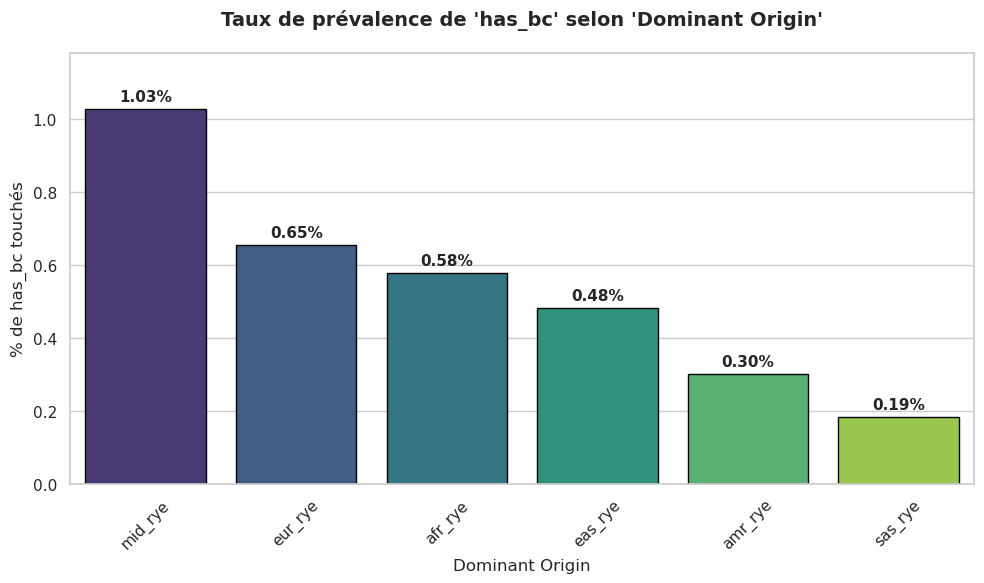

In [43]:
optim_plot_prevalence(df, group_col="dominant_origin", target_col="has_bc")

### Addition of a `admixed_ancestry_80%` column to identify genetic ancestry

In [44]:
threshold = 0.8

def assign_ancestry(row):
    # On s'assure que les données sont numériques (float)
    # errors='coerce' transformera les éventuels textes parasites en NaN
    values = pd.to_numeric(row[pop_cols], errors='coerce')

    # Si toute la ligne est vide (NaN), on renvoie "unknown" ou "admixed"
    if values.isna().all():
        return "unknown"

    # 1️⃣ Cas simple : une population dominante ≥ 0.8
    max_val = values.max()
    if max_val >= threshold:
        return values.idxmax()

    # 2️⃣ Cas mixte : combinaison de 2 populations
    # 0.8 Au total de 2 categories mais < 0.8 dans chaque
    for cat1, cat2 in combinations(pop_cols, 2):
        if (
            row[cat1] < threshold and
            row[cat2] < threshold and
            (row[cat1] + row[cat2]) >= threshold
        ):
            return f"{cat1.replace('_rye','')} / {cat2.replace('_rye','')}"

    # 3️⃣ Sinon : admixed
    return "admixed"

df['ancestry_80'] = df.apply(assign_ancestry, axis=1)

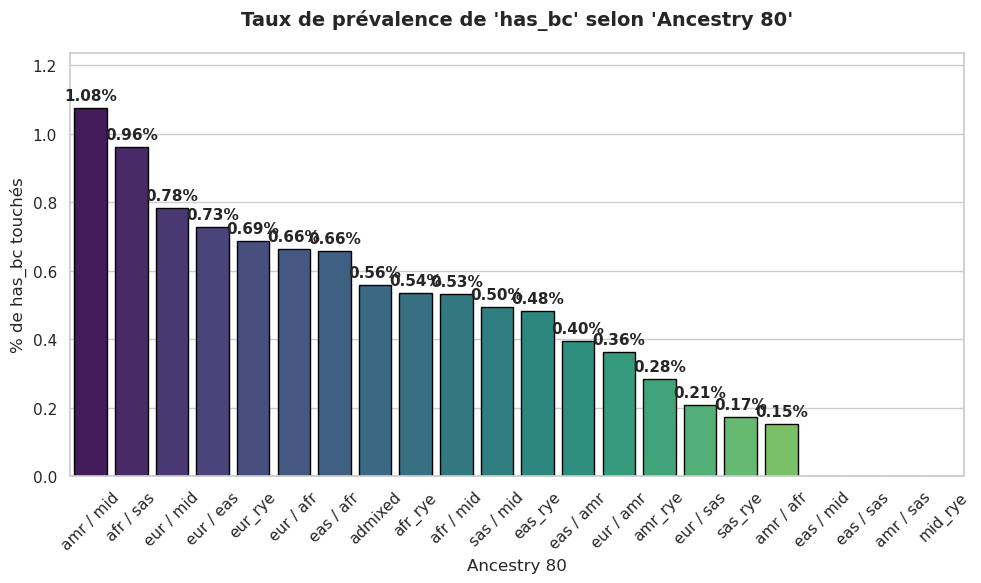

In [45]:
optim_plot_prevalence(df, group_col="ancestry_80", target_col="has_bc")

# Exploratory Data Analysis

In [46]:
df_analysis = df[['person_id','has_bc',
                  'eur_rye', 'eas_rye', 'amr_rye', 'afr_rye','sas_rye', 'mid_rye',
                  'dominant_origin', 'ancestry_80']]

### Number of individuals by category of genetic ancestry < 0.80

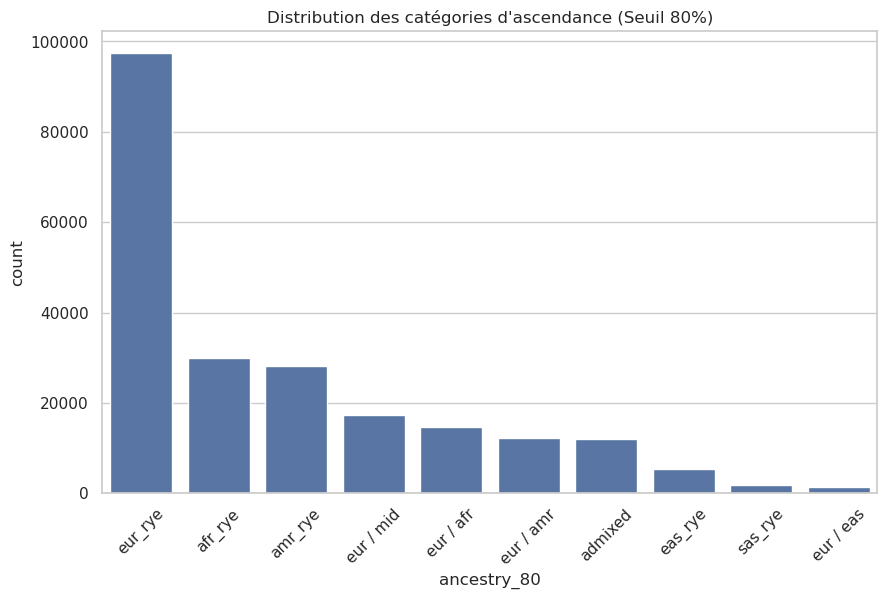

In [47]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df_analysis, x='ancestry_80', order=df['ancestry_80'].value_counts().head(10).index)
plt.title('Distribution des catégories d\'ascendance (Seuil 80%)')
plt.xticks(rotation=45)
plt.show()

### Breakdown of cancer cases by individual `eur_rye`, `afr_rye`,`eur / afr`

In [48]:
ethnie = ['eur_rye', 'afr_rye','eur / afr']

df_analysis[df_analysis['ancestry_80'].isin(ethnie)].value_counts("has_bc")

has_bc
0    140974
1       927
Name: count, dtype: int64

### Breakdown of cancer cases by genetic ancestry category < 0.80

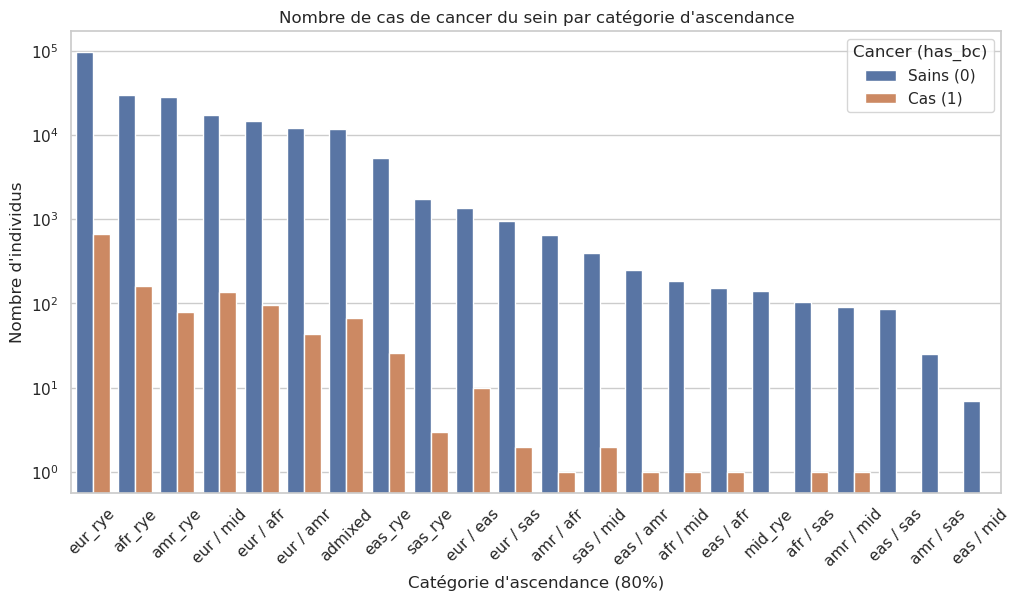

In [49]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df_analysis, x='ancestry_80', hue='has_bc', 
              order=df_analysis['ancestry_80'].value_counts().index)

plt.title('Nombre de cas de cancer du sein par catégorie d\'ascendance')
plt.xlabel('Catégorie d\'ascendance (80%)')
plt.ylabel('Nombre d\'individus')
plt.xticks(rotation=45)
plt.legend(title='Cancer (has_bc)', labels=['Sains (0)', 'Cas (1)'])
plt.yscale('log') # Optionnel : échelle log si les groupes EUR sont trop dominants
plt.show()

# Data's export

In [51]:
# Enregistre le DataFrame `dataset_breast_cancer_5y_person_df` dans un fichier TSV local
destination_filename = 'Datas/df_bc_ko_at_inclusion_223k_nb_BC_WITHIN_5Y_GeneticAncestry.tsv'
df.to_csv(destination_filename, index=False)

# Récupère le nom du bucket Google Cloud depuis la variable d’environnement
my_bucket = os.getenv('WORKSPACE_TEMP_BUCKET')

# Copie le fichier TSV local dans le dossier "Data" du bucket
args = ["gsutil", "cp", f"./{destination_filename}", f"{my_bucket}"]
output = subprocess.run(args, capture_output=True)

# Affiche les éventuelles erreurs retournées par gsutil
output.stderr

b'Copying file://./Datas/df_bc_ko_at_inclusion_223k_nb_BC_WITHIN_5Y_GeneticAncestry.tsv [Content-Type=text/tab-separated-values]...\n/ [0 files][    0.0 B/ 40.3 MiB]                                                \r/ [1 files][ 40.3 MiB/ 40.3 MiB]                                                \r-\r\nOperation completed over 1 objects/40.3 MiB.                                     \n'